In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
dataset = pd.read_csv('loan.csv')
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [6]:
dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


/tmp/ipykernel_1095/1899262194.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])


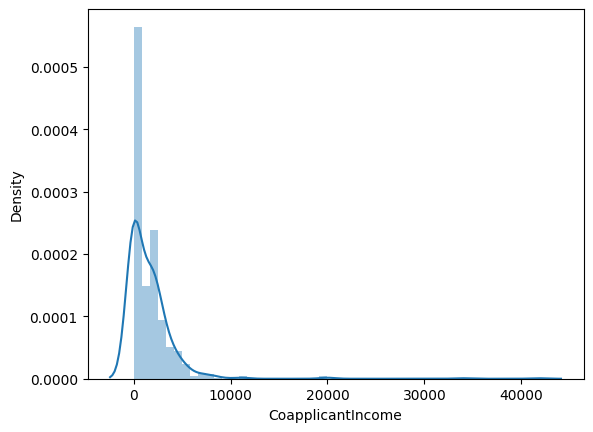

In [8]:
sns.distplot(dataset["CoapplicantIncome"])
plt.show()

In [13]:
q1 = dataset["CoapplicantIncome"].quantile(0.25)

In [15]:
q3 = dataset["CoapplicantIncome"].quantile(0.75)

In [16]:
iqr = q3-q1

In [19]:
min_r = q1-(1.5*iqr)
max_r = q3+(1.5*iqr)
min_r , max_r

(np.float64(-3445.875), np.float64(5743.125))

In [22]:
dataset = dataset[dataset["CoapplicantIncome"]<=max_r]

/tmp/ipykernel_1095/1899262194.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])


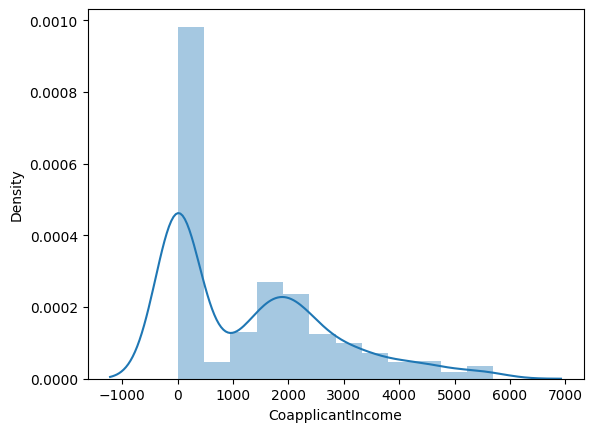

In [26]:
sns.distplot(dataset["CoapplicantIncome"])
plt.show()

In [27]:
from sklearn.preprocessing import FunctionTransformer

In [29]:
ft = FunctionTransformer(np.log1p)
ft.fit(dataset["CoapplicantIncome"])

FunctionTransformer(func=<ufunc 'log1p'>)

In [33]:
dataset["CoapplicantIncome_ft"] = ft.transform(dataset["CoapplicantIncome"])

/tmp/ipykernel_1095/1976267226.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])


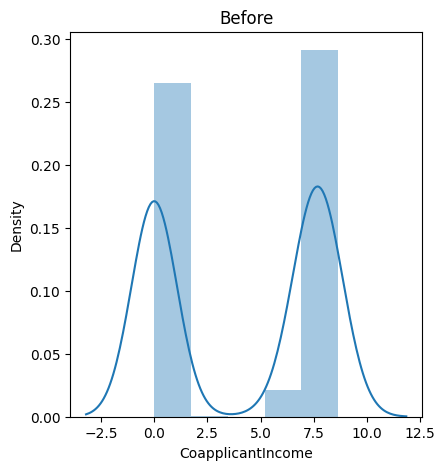

/tmp/ipykernel_1095/1976267226.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome_ft"])


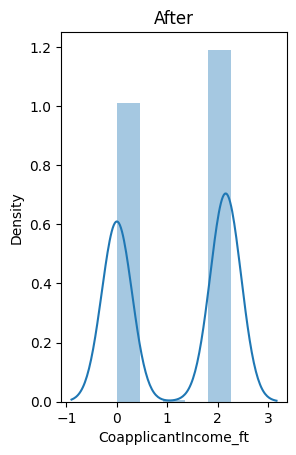

In [40]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.distplot(dataset["CoapplicantIncome"])
plt.title("Before")
plt.show()

plt.subplot(1,2,2)
sns.distplot(dataset["CoapplicantIncome_ft"])
plt.title("After")

plt.show()